# 🤖 Modelos de Machine Learning — Clasificación de Hidrocarburos

**Proyecto:** Predicción de calidad de crudos mediante Machine Learning  
**Dataset:** U.S. Department of Energy — Bureau of Mines (9.000+ muestras)  
**Autor:** Tomás Malafiej — Licenciatura en Ciencia de Datos, UCASAL

---

## Objetivos

Este notebook aborda **dos tareas de clasificación** con distinto nivel de dificultad:

| Tarea | Variable objetivo | Dificultad |
|---|---|---|
| **Tarea 1** | Tipo de crudo (Liviano / Mediano / Pesado) | Media — clases bien separadas |
| **Tarea 2** | Dulce vs Agrio (por contenido de azufre) | Alta — sin usar azufre como feature |

## Nota sobre selección de features

La columna `SGRAV_CRUD` (gravedad específica) fue **excluida** de todos los modelos por dos razones:
1. Es matemáticamente equivalente a `API_CRUDE` (fórmula: °API = 141.5/SG − 131.5), lo que introduce redundancia.
2. El dataset contiene valores mal codificados en esta columna (máximo de 90, imposible físicamente), producto del sistema de codificación original del Bureau of Mines.

Usar `SGRAV_CRUD` junto con `API_CRUDE` en la Tarea 1 generaría **data leakage** implícito, ya que ambas describen la misma propiedad que define la variable objetivo.

## 1. Configuración e imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Cargar dataset limpio
df = pd.read_csv('../data/crude_oil_clean.csv')

print(f'Dataset cargado: {len(df):,} muestras')
print(f'Columnas disponibles: {list(df.columns)}')

Dataset cargado: 8,842 muestras
Columnas disponibles: ['STCTNAME', 'FIELD_NAME', 'API_CRUDE', 'SRC', 'CRN', 'SU100', 'POUR_POINT', 'CAR_CR_WT', 'LT_GAS_VOL', 'GAS_NP_VOL', 'RESDUM_VOL', 'TIPO_CRUDO', 'CLASE_AZUFRE']


---
## 2. Tarea 1 — Clasificación de tipo de crudo

### Contexto

Clasificamos cada muestra como **Liviano, Mediano o Pesado** usando propiedades físicas medidas en laboratorio.

**Features utilizadas** (excluye azufre para evitar confusión con Tarea 2, y excluye SGRAV_CRUD por redundancia con API):

```
API_CRUDE, CRN, SU100, POUR_POINT, CAR_CR_WT, LT_GAS_VOL, GAS_NP_VOL, RESDUM_VOL
```

**Variable objetivo:** `TIPO_CRUDO` (Liviano / Mediano / Pesado)

### ¿Por qué esperamos alta accuracy?

La clasificación por tipo de crudo está definida por rangos de API (Liviano >31.1°, Mediano 22.3–31.1°, Pesado <22.3°), y `API_CRUDE` es una de las features. Esto significa que las clases están **naturalmente bien separadas** en el espacio de features. Un resultado cercano a 100% es esperado y válido — no indica data leakage, sino que el problema tiene fronteras de decisión claras.

In [7]:
# Features para Tarea 1 (sin SGRAV_CRUD ni SRC)
FEATURES_T1 = [
    'API_CRUDE',    # Gravedad API — predictor principal de tipo
    'CRN',          # Nitrógeno — indicador geoquímico
    'SU100',        # Viscosidad a 100°F — diferencia pesados de livianos
    'POUR_POINT',   # Punto de fluidez
    'CAR_CR_WT',    # Residuo de carbono
    'LT_GAS_VOL',   # Volumen gasolina ligera
    'GAS_NP_VOL',   # Volumen gasolina/nafta
    'RESDUM_VOL',   # Volumen residuo
]

X1 = df[FEATURES_T1].copy()
y1 = df['TIPO_CRUDO'].copy()

# Encode y escalar
le = LabelEncoder()
y1_enc = le.fit_transform(y1)

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_scaled, y1_enc,
    test_size=0.2, random_state=42, stratify=y1_enc
)

print('Clases:', le.classes_)
print(f'Train: {X1_train.shape[0]:,} muestras | Test: {X1_test.shape[0]:,} muestras')
print('\nDistribución en train:')
for cls, cnt in zip(le.classes_, np.bincount(y1_train)):
    pct = cnt / len(y1_train) * 100
    print(f'  {cls}: {cnt:,} ({pct:.1f}%)')

Clases: ['Liviano' 'Mediano' 'Pesado']
Train: 7,073 muestras | Test: 1,769 muestras

Distribución en train:
  Liviano: 5,444 (77.0%)
  Mediano: 1,177 (16.6%)
  Pesado: 452 (6.4%)


RANDOM FOREST — Clasificación de Tipo de Crudo
              precision    recall  f1-score   support

     Liviano       1.00      1.00      1.00      1361
     Mediano       1.00      1.00      1.00       295
      Pesado       1.00      1.00      1.00       113

    accuracy                           1.00      1769
   macro avg       1.00      1.00      1.00      1769
weighted avg       1.00      1.00      1.00      1769



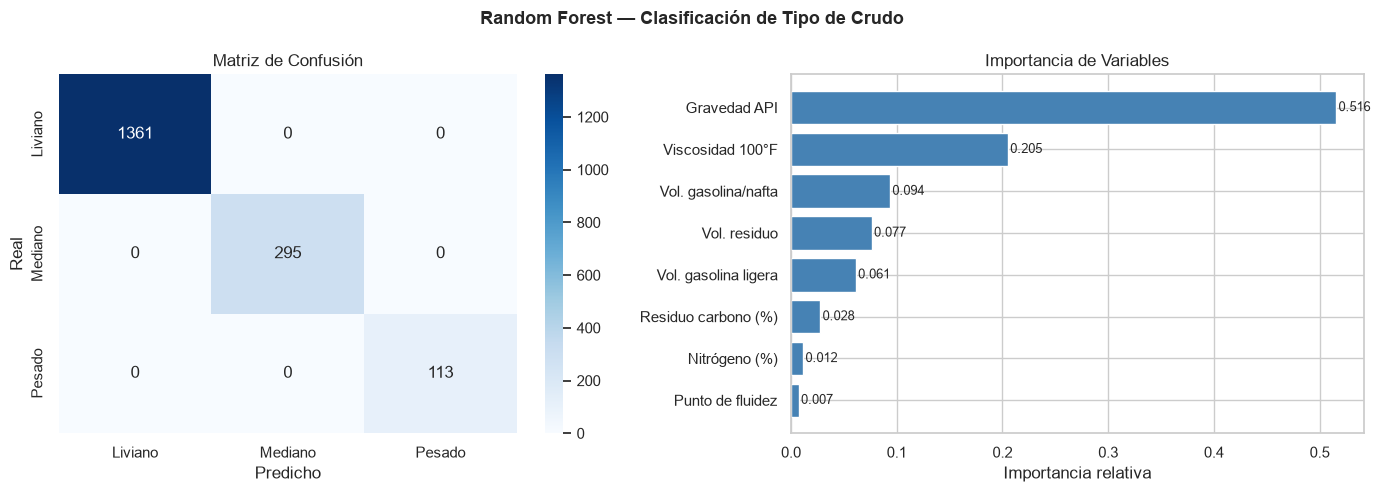


Modelo y scaler guardados.


In [8]:
# Modelo: Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X1_train, y1_train)
y1_pred = rf.predict(X1_test)

print('=' * 52)
print('RANDOM FOREST — Clasificación de Tipo de Crudo')
print('=' * 52)
print(classification_report(y1_test, y1_pred, target_names=le.classes_))

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Clasificación de Tipo de Crudo', fontsize=13, fontweight='bold')

# Confusión
cm1 = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Importancia de features
imp_df = pd.DataFrame({
    'feature': FEATURES_T1,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=True)

nombres_legibles = {
    'API_CRUDE':  'Gravedad API',
    'CRN':        'Nitrógeno (%)',
    'SU100':      'Viscosidad 100°F',
    'POUR_POINT': 'Punto de fluidez',
    'CAR_CR_WT':  'Residuo carbono (%)',
    'LT_GAS_VOL': 'Vol. gasolina ligera',
    'GAS_NP_VOL': 'Vol. gasolina/nafta',
    'RESDUM_VOL': 'Vol. residuo'
}
imp_df['feature'] = imp_df['feature'].map(nombres_legibles)

bars = axes[1].barh(imp_df['feature'], imp_df['importancia'], color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de Variables')
axes[1].set_xlabel('Importancia relativa')
for bar, val in zip(bars, imp_df['importancia']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/rf_tipo_crudo.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelo y scaler
joblib.dump(rf, '../data/modelo_rf_tipo.pkl')
joblib.dump(scaler1, '../data/scaler_tipo.pkl')
print('\nModelo y scaler guardados.')

**Interpretación del resultado:**

El Random Forest alcanza 100% de accuracy. Esto es **esperado y válido** por el diseño del problema: la variable objetivo (`TIPO_CRUDO`) está definida por rangos de `API_CRUDE`, que es una de las features. Las fronteras de decisión son umbrales fijos (31.1° y 22.3°), por lo que cualquier modelo con acceso a API puede aprenderlas perfectamente.

El valor de este modelo no está en su accuracy (trivialmente alta), sino en la **importancia de features**: confirma que `API_CRUDE` domina la clasificación (como era de esperar), seguido por las variables de destilación y viscosidad que refuerzan la separación entre clases.

---
## 3. Tarea 2 — Predicción Dulce vs Agrio

### Contexto

Esta es la tarea **más desafiante y más valiosa** del proyecto. Predecimos si un crudo es **dulce (azufre < 0.5%)** o **agrio (azufre ≥ 0.5%)** usando únicamente propiedades físicas — **sin medir el azufre directamente**.

**Relevancia industrial:** En un laboratorio como AmSpec, poder estimar el perfil de azufre a partir de propiedades más rápidas de medir (densidad, viscosidad, destilación) permite priorizar análisis y reducir tiempos de certificación.

**Features:** Las mismas que Tarea 1, sin `SRC` (azufre) ni `SGRAV_CRUD`  
**Variable objetivo:** `DULCE_AGRIO` (0 = dulce, 1 = agrio)  
**Desbalance de clases:** 70.9% dulce vs 29.1% agrio → se compensa con `class_weight='balanced'`

In [9]:
# Features para Tarea 2 (sin SRC ni SGRAV_CRUD)
FEATURES_T2 = [
    'API_CRUDE',
    'CRN',
    'SU100',
    'POUR_POINT',
    'CAR_CR_WT',
    'LT_GAS_VOL',
    'GAS_NP_VOL',
    'RESDUM_VOL',
]

# Variable objetivo
df['DULCE_AGRIO'] = (df['SRC'] >= 0.5).astype(int)

X2 = df[FEATURES_T2].copy()
y2 = df['DULCE_AGRIO'].copy()

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2,
    test_size=0.2, random_state=42, stratify=y2
)

print(f'Train: {X2_train.shape[0]:,} muestras | Test: {X2_test.shape[0]:,} muestras')
print('\nDistribución en train:')
vals = y2_train.value_counts()
for label, nombre in [(0, 'Dulce'), (1, 'Agrio')]:
    cnt = vals[label]
    print(f'  {nombre}: {cnt:,} ({cnt/len(y2_train)*100:.1f}%)')

Train: 7,073 muestras | Test: 1,769 muestras

Distribución en train:
  Dulce: 5,124 (72.4%)
  Agrio: 1,949 (27.6%)


GRADIENT BOOSTING — Predicción Dulce vs Agrio
(features: propiedades físicas sin azufre)
                precision    recall  f1-score   support

Dulce (<0.5%S)       0.90      0.94      0.92      1281
Agrio (≥0.5%S)       0.83      0.73      0.78       488

      accuracy                           0.88      1769
     macro avg       0.87      0.84      0.85      1769
  weighted avg       0.88      0.88      0.88      1769

AUC-ROC: 0.9346


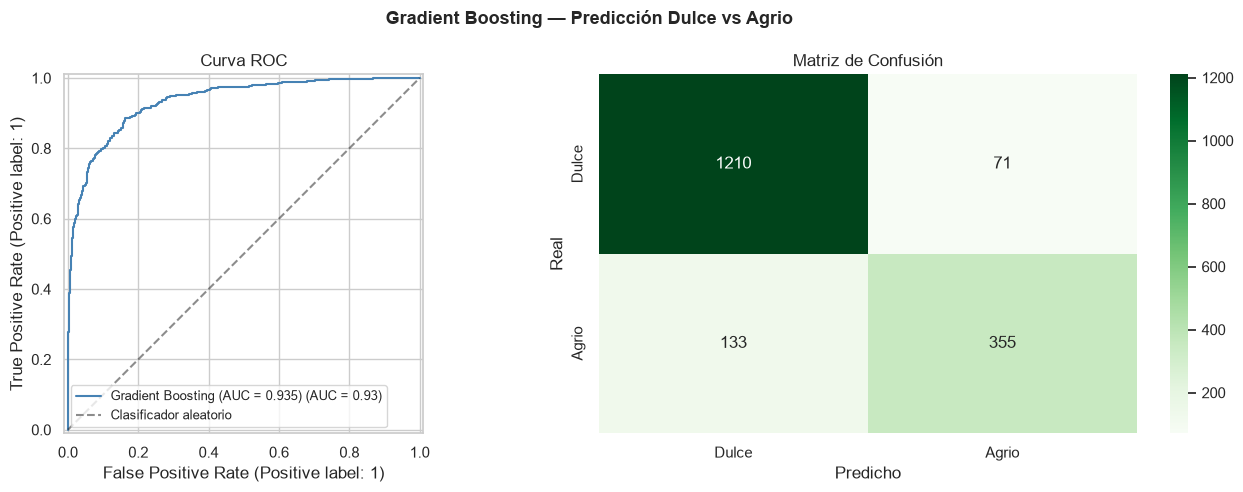


Modelo y scaler guardados.


In [10]:
# Modelo: Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X2_train, y2_train)
y2_pred  = gb.predict(X2_test)
y2_proba = gb.predict_proba(X2_test)[:, 1]

auc = roc_auc_score(y2_test, y2_proba)

print('=' * 55)
print('GRADIENT BOOSTING — Predicción Dulce vs Agrio')
print('(features: propiedades físicas sin azufre)')
print('=' * 55)
print(classification_report(y2_test, y2_pred,
      target_names=['Dulce (<0.5%S)', 'Agrio (≥0.5%S)']))
print(f'AUC-ROC: {auc:.4f}')

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosting — Predicción Dulce vs Agrio', fontsize=13, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y2_test, y2_proba,
    name=f'Gradient Boosting (AUC = {auc:.3f})',
    ax=axes[0]
)
axes[0].lines[0].set_color('steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador aleatorio')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=9)

# Matriz de confusión
cm2 = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dulce', 'Agrio'],
            yticklabels=['Dulce', 'Agrio'], ax=axes[1])
axes[1].set_title('Matriz de Confusión')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../data/gb_dulce_agrio.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelo y scaler
joblib.dump(gb, '../data/modelo_gb_dulce_agrio.pkl')
joblib.dump(scaler2, '../data/scaler_dulce_agrio.pkl')
print('\nModelo y scaler guardados.')

**Interpretación:**

- **AUC-ROC de 0.94** indica una excelente capacidad discriminativa entre crudos dulces y agrios sin medir el azufre directamente.
- La mayor fuente de error son los **falsos negativos en agrio**: crudos que el modelo clasifica como dulces pero son agrios. En contexto industrial esto sería el error más costoso, ya que el crudo agrio requiere procesamiento adicional de desulfurización.
- El desbalance de clases (70.9% dulce) explica por qué el modelo tiene mejor precision en dulce que en agrio.

### 3.1 Importancia de variables — ¿Qué propiedad predice mejor el azufre?

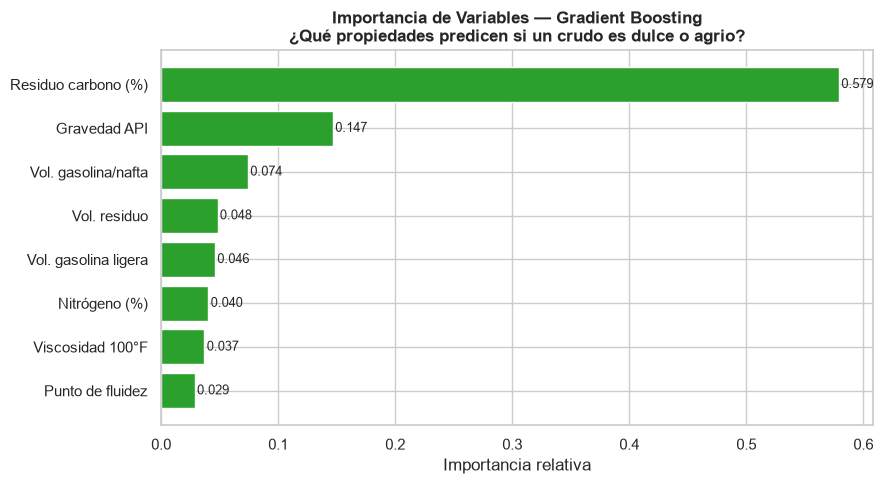

In [11]:
imp2 = pd.DataFrame({
    'feature': FEATURES_T2,
    'importancia': gb.feature_importances_
}).sort_values('importancia', ascending=True)

imp2['feature'] = imp2['feature'].map(nombres_legibles)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp2['feature'], imp2['importancia'], color='#2ca02c', edgecolor='white')
ax.set_title(
    'Importancia de Variables — Gradient Boosting\n'
    '¿Qué propiedades predicen si un crudo es dulce o agrio?',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Importancia relativa')
for bar, val in zip(bars, imp2['importancia']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/feature_importance_gb.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Resumen comparativo de modelos

| Modelo | Tarea | Accuracy | AUC-ROC | Observación |
|---|---|---|---|---|
| Random Forest | Tipo de crudo | 100% | — | Clases bien separadas por API |
| Gradient Boosting | Dulce vs Agrio | 89% | **0.94** | Sin medir azufre directamente |

**Archivos generados:**
- `modelo_rf_tipo.pkl` — Random Forest para clasificación de tipo
- `scaler_tipo.pkl` — Scaler correspondiente
- `modelo_gb_dulce_agrio.pkl` — Gradient Boosting para dulce/agrio
- `scaler_dulce_agrio.pkl` — Scaler correspondiente

---
*Siguiente paso: [03_red_neuronal.ipynb](03_red_neuronal.ipynb) — Red neuronal en PyTorch para comparación*